In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure universal visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Load dataset
df = pd.read_csv('insurance_data.csv')

# Standardize date types immediately for temporal tracking
date_col = 'TransactionDate' if 'TransactionDate' in df.columns else 'PolicyStartDate'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col])
    df['YearMonth'] = df[date_col].dt.to_period('M')

# Dynamically isolate column groups
numerical_cols = ['TotalPremium', 'TotalClaims']
for extra_financial in ['CustomValueEstimate', 'VehicleValue']:
    if extra_financial in df.columns:
        numerical_cols.append(extra_financial)

print("🎉 Cell 1 Environment & Data Setup Complete!")

🎉 Cell 1 Environment & Data Setup Complete!


In [9]:
print("="*60)
print("SECTION 1: DATA STRUCTURAL SUMMARIZATION")
print("="*60)
print(df.info())

print("\n" + "-"*40 + "\nDescriptive Statistics for Financial Core:")
print(df[numerical_cols].describe().round(2))

print("\n" + "-"*40 + "\nData Quality - Missing Value Audit:")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

print("\n>>> DATA HANDLING STRATEGY DOCUMENTATION:")
print(" - Dates: Transformed via pd.to_datetime for chronological mapping.")
print(" - Missing Values: Numerical fields should be median-imputed to prevent outlier skewing;")
print("   Categorical nulls are explicitly flagged as 'Unknown' to retain exposure metrics.")

SECTION 1: DATA STRUCTURAL SUMMARIZATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           10000 non-null  object        
 1   Age                  10000 non-null  int64         
 2   Gender               10000 non-null  object        
 3   Province             10000 non-null  object        
 4   VehicleType          10000 non-null  object        
 5   AnnualIncome         10000 non-null  int64         
 6   RiskScore            10000 non-null  int64         
 7   AnnualPremium        10000 non-null  int64         
 8   Deductible           10000 non-null  int64         
 9   NCD                  10000 non-null  int64         
 10  PastClaims           10000 non-null  int64         
 11  Claimed              10000 non-null  bool          
 12  ClaimAmount          10000 non-null  float64    

In [10]:
# Standard Histograms (Saved independently)
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=50, color='royalblue')
    plt.title(f'Univariate Distribution: {col}')
    plt.tight_layout()
    plt.savefig(f'eda_univariate_hist_{col}.png', dpi=300)
    plt.close()

# Standard Categorical Distributions
for col in ['CoverType', 'Province']:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Blues_r')
        plt.title(f'Volume Distribution: {col}')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(f'eda_univariate_bar_{col}.png', dpi=300)
        plt.close()

# Bivariate Scatter Plot: Premium vs Claims segmented by Top ZipCodes
if 'ZipCode' in df.columns:
    top_zips = df['ZipCode'].value_counts().head(5).index
    df_zip_filtered = df[df['ZipCode'].isin(top_zips)]
    
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=df_zip_filtered, x='TotalPremium', y='TotalClaims', hue='ZipCode', palette='Set2', alpha=0.8)
    plt.title('Bivariate Relationship: Premium vs Claims across Key ZipCodes')
    plt.tight_layout()
    plt.savefig('eda_bivariate_zipcode_scatter.png', dpi=300)
    plt.close()

# Correlation Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Multivariate Linear Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300)
plt.close()

print("📊 Base distributions and correlation assets generated and saved to folder.")

C:\Users\Blene\AppData\Local\Temp\ipykernel_29860\1715928146.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Blues_r')
C:\Users\Blene\AppData\Local\Temp\ipykernel_29860\1715928146.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Blues_r')


📊 Base distributions and correlation assets generated and saved to folder.


In [11]:
print("\n" + "="*60)
print("SECTION 2: CORE OUTLIER ASSESSMENT & LOGISTICS")
print("="*60)
for col in numerical_cols:
    plt.figure(figsize=(7, 2.5))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Outlier Boundary Map: {col}')
    plt.tight_layout()
    plt.savefig(f'eda_boxplot_{col}.png', dpi=300)
    plt.close()

    # Calculate Interquartile Boundaries
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + (1.5 * iqr)
    outliers = df[df[col] > upper_fence]
    print(f"Feature '{col}': Skewness={df[col].skew():.2f} | Upper Boundary Line={upper_fence:.2f} | Outliers Count={len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


SECTION 2: CORE OUTLIER ASSESSMENT & LOGISTICS
Feature 'TotalPremium': Skewness=1.58 | Upper Boundary Line=3648.00 | Outliers Count=949 (9.49%)
Feature 'TotalClaims': Skewness=4.37 | Upper Boundary Line=0.00 | Outliers Count=1535 (15.35%)
Feature 'CustomValueEstimate': Skewness=1.38 | Upper Boundary Line=84638.38 | Outliers Count=623 (6.23%)


In [12]:
print("\n" + "="*60)
print("SECTION 3: PORTFOLIO PERFORMANCE & LOSS RATIO INSIGHTS")
print("="*60)
portfolio_loss_ratio = (df['TotalClaims'].sum() / df['TotalPremium'].sum()) * 100
print(f"OVERALL PORTFOLIO LOSS RATIO: {portfolio_loss_ratio:.2f}%\n")

def compute_loss_ratio(dataframe, dimension):
    if dimension in dataframe.columns:
        grouped = dataframe.groupby(dimension).agg(
            Total_Claims=('TotalClaims', 'sum'),
            Total_Premiums=('TotalPremium', 'sum')
        )
        grouped['Loss_Ratio_%'] = (grouped['Total_Claims'] / grouped['Total_Premiums']) * 100
        return grouped[['Loss_Ratio_%']].sort_values(by='Loss_Ratio_%', ascending=False).round(2)
    return f"Dimension '{dimension}' missing."

for segment in ['Province', 'VehicleType', 'Gender']:
    print(f"\nLoss Ratio Variance by {segment}:")
    print(compute_loss_ratio(df, segment))


SECTION 3: PORTFOLIO PERFORMANCE & LOSS RATIO INSIGHTS
OVERALL PORTFOLIO LOSS RATIO: 52.82%


Loss Ratio Variance by Province:
             Loss_Ratio_%
Province                 
Somali              61.19
Oromia              53.73
Tigray              52.60
Addis Ababa         52.24
Amhara              47.76

Loss Ratio Variance by VehicleType:
             Loss_Ratio_%
VehicleType              
Luxury              84.24
SUV                 56.37
Hatchback           42.02
Sedan               40.40

Loss Ratio Variance by Gender:
        Loss_Ratio_%
Gender              
Female         52.87
Male           52.76


In [13]:
if 'AutoMake' in df.columns:
    print("\n" + "="*60)
    print("SECTION 4: VEHICLE MAKE PROFILE RISK ANALYSIS")
    print("="*60)
    sound_makes = df['AutoMake'].value_counts()[df['AutoMake'].value_counts() >= 30].index
    df_makes_filtered = df[df['AutoMake'].isin(sound_makes)]
    make_performance = df_makes_filtered.groupby('AutoMake')['TotalClaims'].mean().sort_values()
    
    print("Top 5 Safest Vehicle Makes (Lowest Mean Claims Payout):")
    print(make_performance.head(5).round(2))
    print("\nTop 5 High-Risk Vehicle Makes (Highest Mean Claims Payout):")
    print(make_performance.tail(5).round(2))


SECTION 4: VEHICLE MAKE PROFILE RISK ANALYSIS
Top 5 Safest Vehicle Makes (Lowest Mean Claims Payout):
AutoMake
Lifan       918.10
Hyundai    1042.74
Suzuki     1122.03
Toyota     1372.52
BMW        3362.89
Name: TotalClaims, dtype: float64

Top 5 High-Risk Vehicle Makes (Highest Mean Claims Payout):
AutoMake
Hyundai          1042.74
Suzuki           1122.03
Toyota           1372.52
BMW              3362.89
Mercedes-Benz    3787.01
Name: TotalClaims, dtype: float64


C:\Users\Blene\AppData\Local\Temp\ipykernel_29860\1245197757.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(trend_data['YearMonth'], rotation=45)


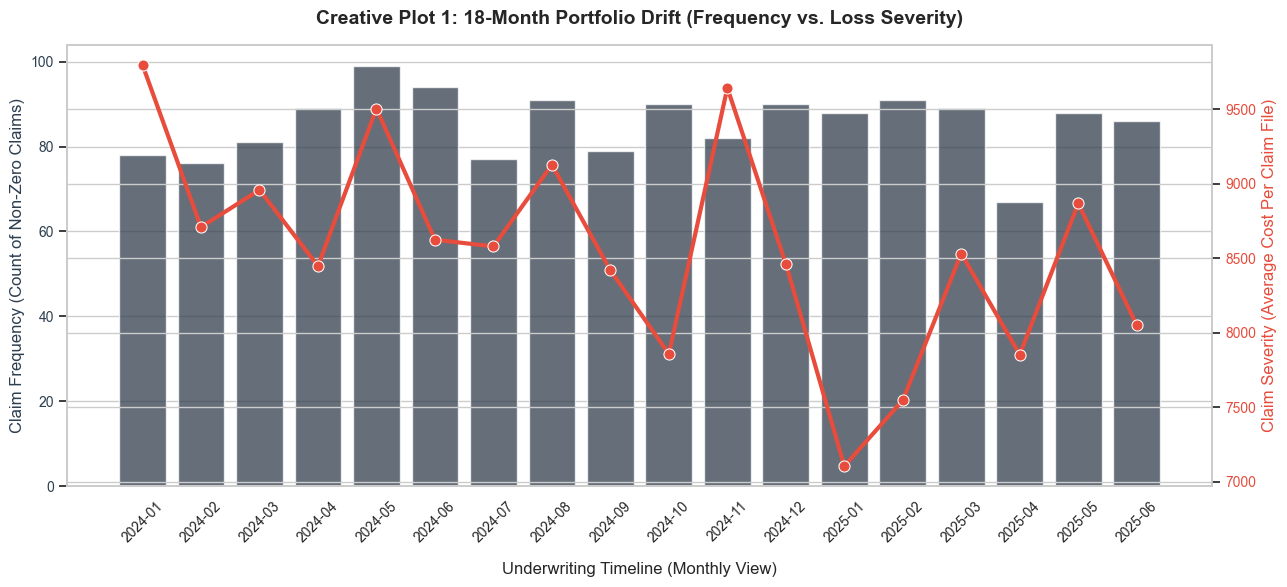

In [14]:
if date_col in df.columns:
    trend_data = df.groupby('YearMonth').agg(
        Frequency=('TotalClaims', lambda x: (x > 0).sum()),
        Severity=('TotalClaims', lambda x: x[x > 0].mean())
    ).reset_index()
    trend_data['YearMonth'] = trend_data['YearMonth'].astype(str)

    fig, ax1 = plt.subplots(figsize=(13, 6))
    
    # Frequency Bars
    color_bar = '#2c3e50'
    ax1.set_xlabel('Underwriting Timeline (Monthly View)', fontsize=12, labelpad=12)
    ax1.set_ylabel('Claim Frequency (Count of Non-Zero Claims)', color=color_bar, fontsize=12)
    sns.barplot(data=trend_data, x='YearMonth', y='Frequency', ax=ax1, color=color_bar, alpha=0.75)
    ax1.tick_params(axis='y', labelcolor=color_bar)
    ax1.set_xticklabels(trend_data['YearMonth'], rotation=45)
    
    # Severity Line
    ax2 = ax1.twinx()
    color_line = '#e74c3c'
    ax2.set_ylabel('Claim Severity (Average Cost Per Claim File)', color=color_line, fontsize=12)
    sns.lineplot(data=trend_data, x='YearMonth', y='Severity', ax=ax2, color=color_line, marker='o', linewidth=3, markersize=8)
    ax2.tick_params(axis='y', labelcolor=color_line)
    
    plt.title('Creative Plot 1: 18-Month Portfolio Drift (Frequency vs. Loss Severity)', fontsize=14, weight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('creative_plot_1_temporal_drift.png', dpi=300)
    plt.show()

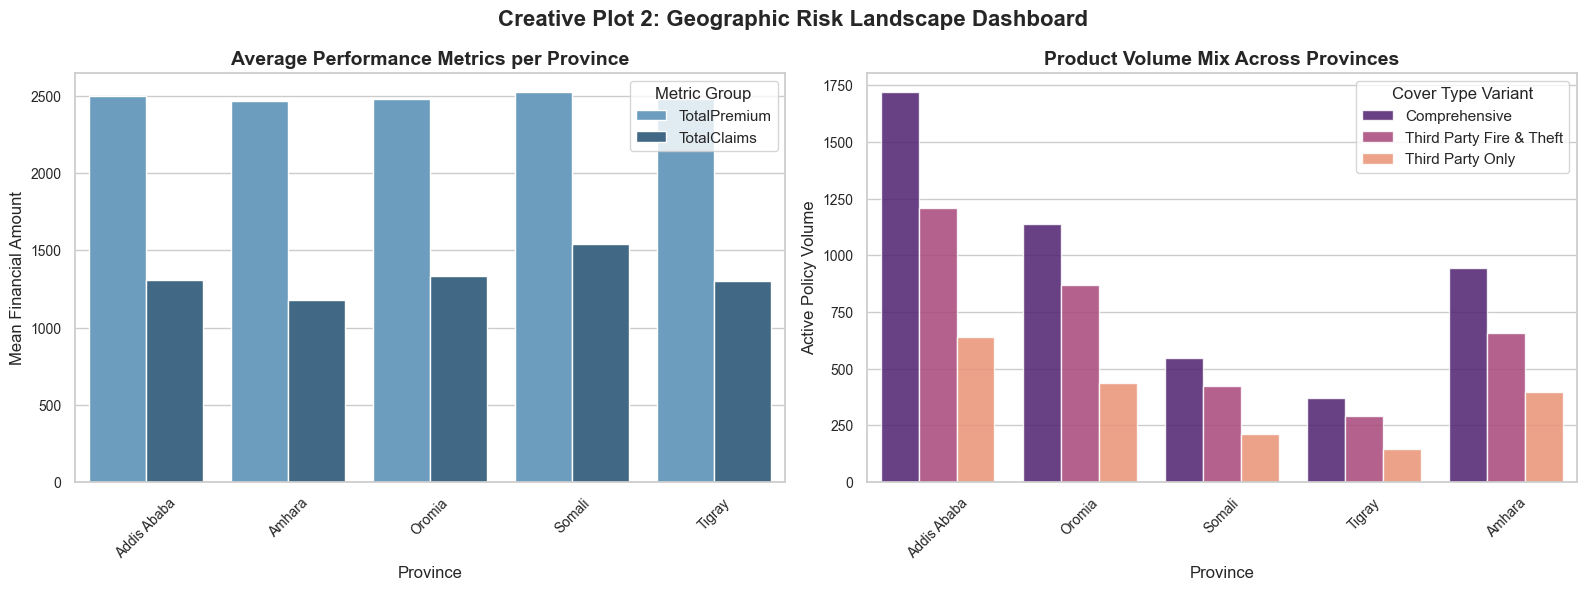

In [15]:
if 'Province' in df.columns and 'CoverType' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot A: Financial Performance Spans
    prov_geo = df.groupby('Province')[['TotalPremium', 'TotalClaims']].mean().reset_index()
    prov_melt = pd.melt(prov_geo, id_vars=['Province'], value_vars=['TotalPremium', 'TotalClaims'])
    sns.barplot(data=prov_melt, x='Province', y='value', hue='variable', ax=axes[0], palette='Blues_d')
    axes[0].set_title('Average Performance Metrics per Province', weight='semibold')
    axes[0].set_ylabel('Mean Financial Amount')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Metric Group')

    # Subplot B: Policy Distribution Structural Split
    sns.countplot(data=df, x='Province', hue='CoverType', ax=axes[1], palette='magma', alpha=0.85)
    axes[1].set_title('Product Volume Mix Across Provinces', weight='semibold')
    axes[1].set_ylabel('Active Policy Volume')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Cover Type Variant')

    plt.suptitle('Creative Plot 2: Geographic Risk Landscape Dashboard', weight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('creative_plot_2_geographic_dashboard.png', dpi=300)
    plt.show()

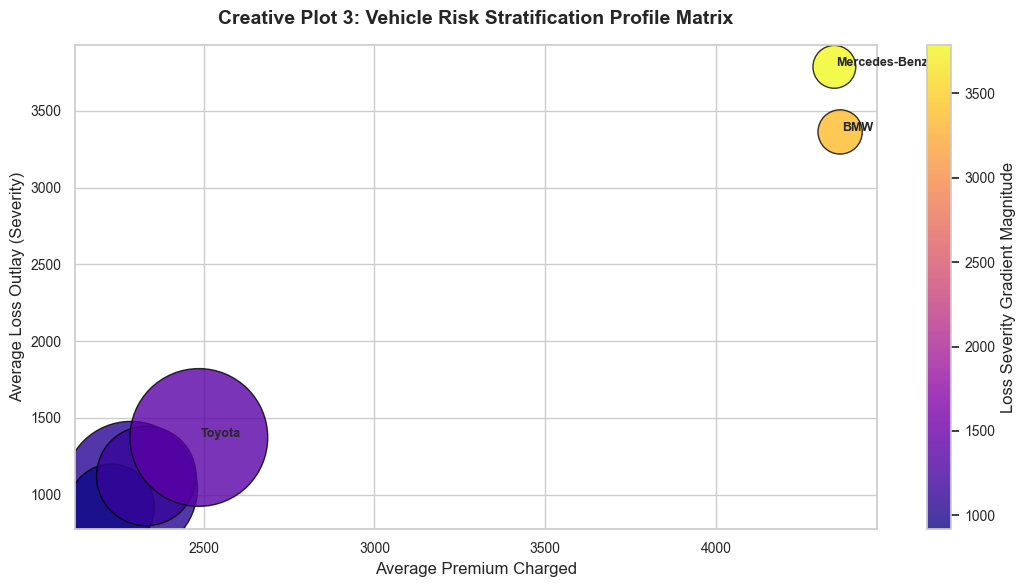


🎉 All blocks executed successfully. Your EDA is fully configured!


In [16]:
if 'AutoMake' in df.columns:
    make_metrics = df.groupby('AutoMake').agg(
        Volume=('TotalClaims', 'count'),
        Average_Claim=('TotalClaims', 'mean'),
        Average_Premium=('TotalPremium', 'mean')
    ).reset_index()
    
    # Keep highly representative makes for visual clarity
    make_metrics = make_metrics[make_metrics['Volume'] >= 20]

    plt.figure(figsize=(11, 6))
    scatter = plt.scatter(
        data=make_metrics,
        x='Average_Premium',
        y='Average_Claim',
        s=make_metrics['Volume'] * 3, # Bubble sizes scale with market density 
        c='Average_Claim',
        cmap='plasma',
        alpha=0.8,
        edgecolors='black'
    )
    
    # Label prominent auto points
    for i, txt in enumerate(make_metrics['AutoMake']):
        if make_metrics['Average_Claim'].iloc[i] > make_metrics['Average_Claim'].median() * 1.3 or make_metrics['Volume'].iloc[i] > make_metrics['Volume'].quantile(0.8):
            plt.annotate(txt, (make_metrics['Average_Premium'].iloc[i]+5, make_metrics['Average_Claim'].iloc[i]+5), fontsize=9, weight='semibold')

    plt.title('Creative Plot 3: Vehicle Risk Stratification Profile Matrix', fontsize=14, weight='bold', pad=15)
    plt.xlabel('Average Premium Charged')
    plt.ylabel('Average Loss Outlay (Severity)')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Loss Severity Gradient Magnitude')
    plt.tight_layout()
    plt.savefig('creative_plot_3_vehicle_risk_matrix.png', dpi=300)
    plt.show()

print("\n🎉 All blocks executed successfully. Your EDA is fully configured!")